# Distributed Penalty Method Verification (S1 + S2 + S3)

Single-MPC-step verification that `solve_penalty_method` produces
sensible trajectories on the three benchmark scenarios used in the
Optimization-course comparison, alongside Consensus ADMM and the
centralized QP reference.

Scenarios:
1. **S1** — two-drone antipodal swap on a complete graph (matches
   notebook 01 test 2).
2. **S2** — four-drone ring antipodal swap (communication limited to
   ring neighbors; opposite-drone pairs are intentionally unconstrained).
3. **S3** — eight-drone complete-graph antipodal swap (scalability test,
   N=8 per the proposal).

Final sub-experiment sweeps the penalty weight `w` on S2 to illustrate the
feasibility vs. conditioning tradeoff.

In [1]:
# Google Colab setup (no-op on local runs)
import sys, os
if "google.colab" in sys.modules:
    print("Google Colab detected. Setting up environment...")
    REPO_URL = "https://github.com/chrisjinyu/distributed-trajectory-planning.git"
    REPO_DIR = "distributed-trajectory-planning"
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}
    if os.path.basename(os.getcwd()) != REPO_DIR:
        os.chdir(REPO_DIR)
    !pip install -q -e .
    print("Colab setup complete.")
else:
    print("Local environment detected. Assuming `uv sync` has already been run.")

Local environment detected. Assuming `uv sync` has already been run.


In [2]:
import sys, pathlib
# Make the repo root importable so `experiments.runner` resolves.
_ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from experiments.runner import (
    load_scenario,
    run_penalty,
    run_admm,
    run_centralized,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Experiment 1: S1 — Two-drone antipodal swap

Both drones must dodge each other at the origin. This is a sanity check
that the penalty method reaches the goal and keeps the min pairwise
distance near `d_min`.

In [3]:
scn1 = load_scenario("../experiments/configs/two_drone_swap.yaml")
print(f"S1: N={scn1.N}, H={scn1.H}, d_min={scn1.d_min}, edges={list(scn1.graph.edges())}")

pr1 = run_penalty(scn1, w=1e3, max_iter=80)
ar1 = run_admm(scn1, rho=5.0, max_iter=200)
# Seed centralized's collision normals from the penalty solution so the
# straight-line antipodal symmetry doesn't trap the SCP loop in a 1D pass.
cr1 = run_centralized(scn1, scp_iters=5, linearization_from=pr1.x)

header = f"{'method':24s} {'iters':>6s} {'t (s)':>8s} {'objective':>12s} {'viol':>10s} {'min_d':>8s}"
print(header); print("-" * len(header))
for r in [pr1, ar1, cr1]:
    print(f"{r.name:24s} {r.iterations:>6d} {r.wall_time:>8.2f} "
          f"{r.final_objective:>12.3f} {r.max_collision_violation:>10.3e} "
          f"{r.min_pairwise_distance:>8.3f}")

S1: N=2, H=20, d_min=0.5, edges=[(0, 1)]


method                    iters    t (s)    objective       viol    min_d
-------------------------------------------------------------------------
penalty (w=1000)             77     0.37     4465.754  1.768e-02    0.482
ADMM (rho=5)                 56     0.29     4466.636  0.000e+00    0.514
centralized                   5     0.28     4466.239  0.000e+00    0.500


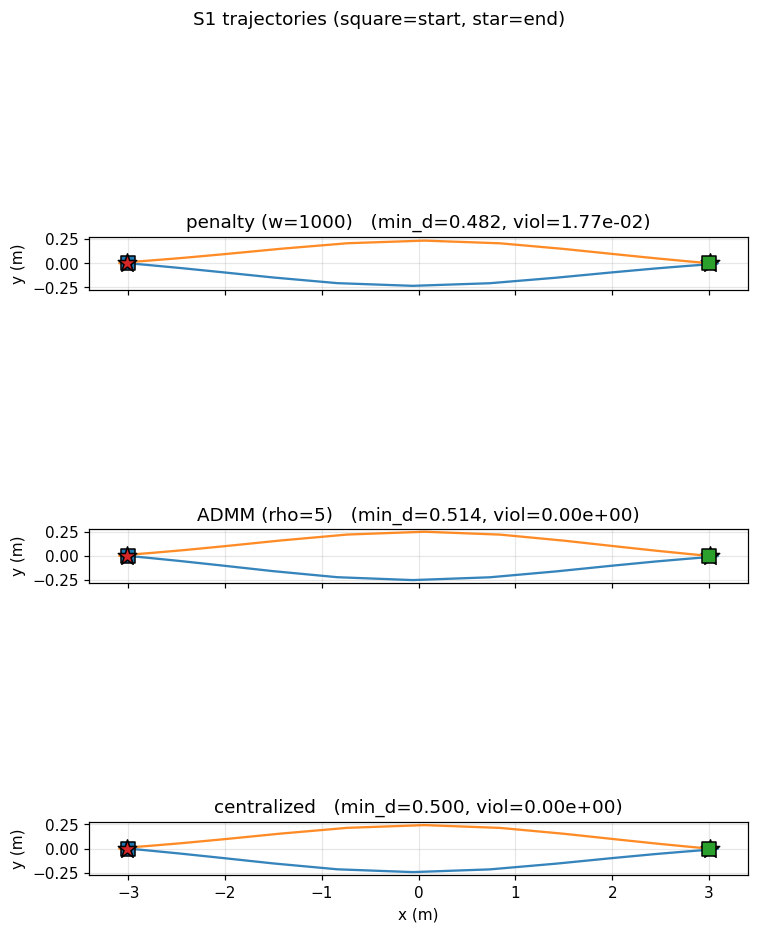

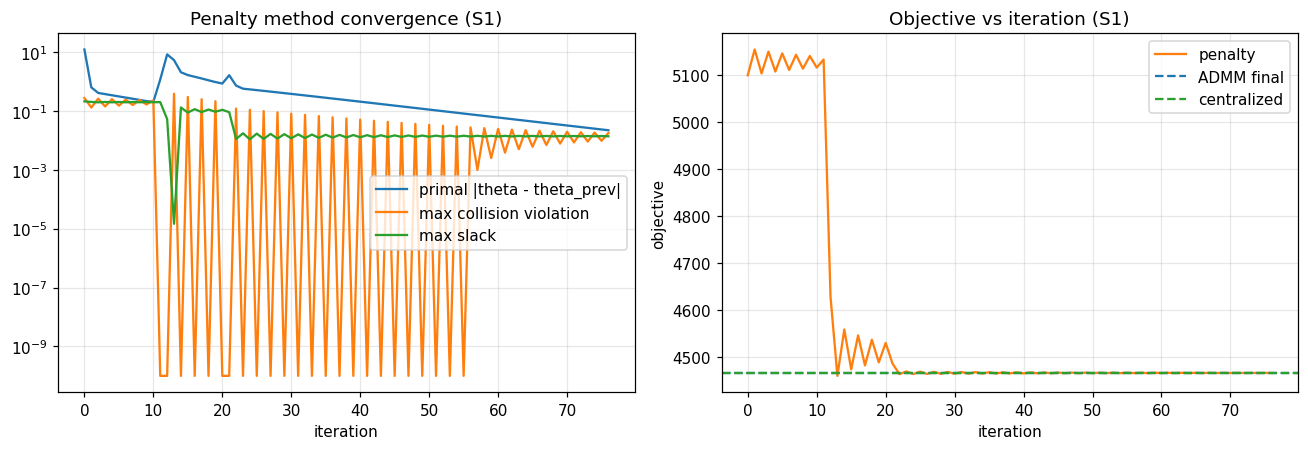

In [4]:
# Trajectory plot for S1 — one row per method
fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True, sharey=True)
for ax, r in zip(axes, [pr1, ar1, cr1]):
    for i in range(scn1.N):
        p = r.x[i, :, 0:2]
        ax.plot(p[:, 0], p[:, 1], "-", alpha=0.9)
        ax.scatter(p[0, 0], p[0, 1], marker="s", s=80, edgecolor="k", zorder=5)
        ax.scatter(p[-1, 0], p[-1, 1], marker="*", s=160, edgecolor="k", zorder=5)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{r.name}   (min_d={r.min_pairwise_distance:.3f}, viol={r.max_collision_violation:.2e})")
axes[-1].set_xlabel("x (m)")
for ax in axes:
    ax.set_ylabel("y (m)")
fig.suptitle("S1 trajectories (square=start, star=end)")
plt.tight_layout()
plt.show()

# Convergence + objective traces for the penalty run
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.semilogy(pr1.history.primal_residual, label="primal |theta - theta_prev|")
ax1.semilogy([max(v, 1e-10) for v in pr1.history.constraint_violation], label="max collision violation")
ax1.semilogy([max(s, 1e-10) for s in pr1.history.max_slack], label="max slack")
ax1.set_xlabel("iteration"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.set_title("Penalty method convergence (S1)")

ax2.plot(pr1.history.objective, color="tab:orange", label="penalty")
ax2.axhline(ar1.history.objective[-1], color="tab:blue", ls="--", label="ADMM final")
ax2.axhline(cr1.final_objective, color="tab:green", ls="--", label="centralized")
ax2.set_xlabel("iteration"); ax2.set_ylabel("objective")
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_title("Objective vs iteration (S1)")
plt.tight_layout()
plt.show()


## Experiment 2: S2 — Four-drone ring antipodal swap

Four drones placed at 0°/90°/180°/270° on a radius-3 circle swap to
antipodal points. Each drone shares collision constraints only with its
two ring-neighbors (opposite-drone pairs 0-2 and 1-3 are intentionally
unconstrained).

In [5]:
scn2 = load_scenario("../experiments/configs/four_drone_ring.yaml")
print(f"S2: N={scn2.N}, H={scn2.H}, d_min={scn2.d_min}, edges={list(scn2.graph.edges())}")

pr2 = run_penalty(scn2, w=1e3, max_iter=120)
ar2 = run_admm(scn2, rho=5.0, max_iter=300)
cr2 = run_centralized(scn2, scp_iters=5, linearization_from=pr2.x)

header = f"{'method':24s} {'iters':>6s} {'t (s)':>8s} {'objective':>12s} {'viol':>10s} {'min_d':>8s}"
print(header); print("-" * len(header))
for r in [pr2, ar2, cr2]:
    print(f"{r.name:24s} {r.iterations:>6d} {r.wall_time:>8.2f} "
          f"{r.final_objective:>12.3f} {r.max_collision_violation:>10.3e} "
          f"{r.min_pairwise_distance:>8.3f}")

S2: N=4, H=25, d_min=0.5, edges=[(0, 1), (0, 3), (1, 2), (2, 3)]


method                    iters    t (s)    objective       viol    min_d
-------------------------------------------------------------------------
penalty (w=1000)             99     1.29     8944.797  1.674e-02    0.483
ADMM (rho=5)                 31     0.58     8948.308  0.000e+00    0.514
centralized                   5     0.73     8946.626  0.000e+00    0.500


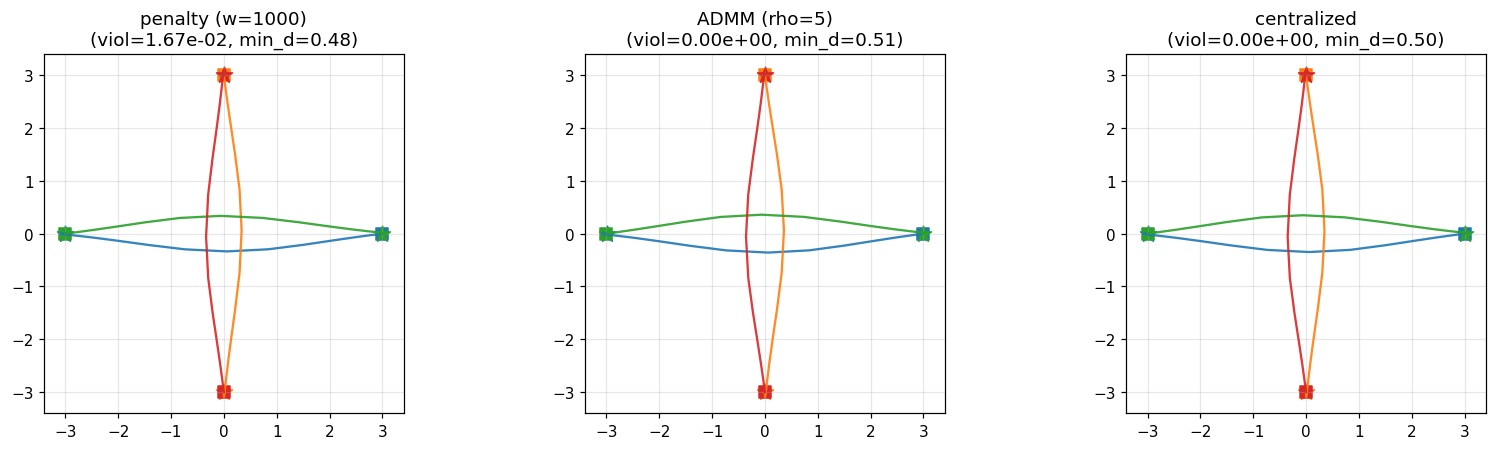

In [6]:
# Trajectory + convergence plots for S2
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
colors = plt.cm.tab10(np.arange(scn2.N))

# Each panel: trajectories for one method
for ax, r in zip(axes, [pr2, ar2, cr2]):
    for i in range(scn2.N):
        p = r.x[i, :, 0:2]
        ax.plot(p[:, 0], p[:, 1], "-", color=colors[i], alpha=0.9)
        ax.scatter(p[0, 0], p[0, 1], marker="s", color=colors[i], s=60)
        ax.scatter(p[-1, 0], p[-1, 1], marker="*", color=colors[i], s=120)
    ax.set_aspect("equal")
    ax.set_title(r.name + f"\n(viol={r.max_collision_violation:.2e}, min_d={r.min_pairwise_distance:.2f})")
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

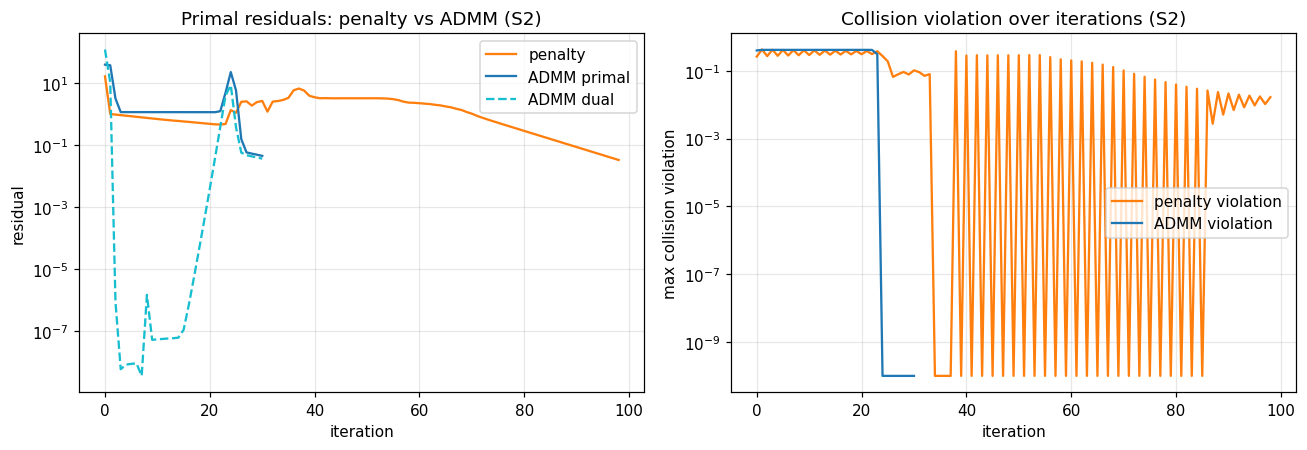

In [7]:
# Convergence comparison on S2: penalty vs ADMM primal residual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

ax1.semilogy(pr2.history.primal_residual, color="tab:orange", label="penalty")
ax1.semilogy(ar2.history.primal_residual, color="tab:blue", label="ADMM primal")
ax1.semilogy(ar2.history.dual_residual, color="tab:cyan", ls="--", label="ADMM dual")
ax1.set_xlabel("iteration"); ax1.set_ylabel("residual")
ax1.set_title("Primal residuals: penalty vs ADMM (S2)")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.semilogy([max(v, 1e-10) for v in pr2.history.constraint_violation],
             color="tab:orange", label="penalty violation")
ax2.semilogy([max(v, 1e-10) for v in ar2.history.constraint_violation],
             color="tab:blue", label="ADMM violation")
ax2.set_xlabel("iteration"); ax2.set_ylabel("max collision violation")
ax2.set_title("Collision violation over iterations (S2)")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## Experiment 3: S3 — Eight-drone complete-graph antipodal swap (scalability)

Eight drones placed at 45-degree intervals on a radius-3 circle swap to
antipodal points. S3 uses a **complete communication graph** so every
pair is directly constrained, isolating the scalability-in-N question
from graph-sparsity effects.

**ADMM tuning needed at N=8.** The default straight-line warm-start is
degenerate at N=8 (all 8 drones cross the origin at the same time step),
which traps standard ADMM at a broken fixed point regardless of `rho`.
Two changes unstick it:

1. **Seed `initial_guess` from the penalty solution.** Penalty already
   runs and produces a non-degenerate (if imperfect) trajectory.
2. **Raise `rho` to ~300 and `collision_slack_weight` to ~1e7.**
   The dual forces have to build up faster than each agent's own
   tracking cost can collapse the plan back to a straight line.

With those changes, ADMM reaches the same feasibility as centralized
(`viol ~ 1e-5`). Diagnostic sweep lives in `experiments/try_admm_s3.py`.


In [8]:
scn3 = load_scenario("../experiments/configs/eight_drone_complete.yaml")
print(f"S3: N={scn3.N}, H={scn3.H}, d_min={scn3.d_min}, #edges={len(list(scn3.graph.edges()))}")

# Penalty uses w=2000 (tuned up from w=1000 used in S1/S2 because N=8
# coupling is tighter). This penalty solution also seeds ADMM and
# centralized's linearization.
pr3 = run_penalty(scn3, w=2e3, max_iter=500)

# ADMM at N=8 needs a penalty-seeded initial guess + much higher rho
# and collision_slack_weight to escape the symmetric straight-line trap.
# Tolerances are Boyd-Parikh-Chu defaults -- see the S3 markdown above.
ar3 = run_admm(
    scn3, rho=300.0, max_iter=500,
    eps_abs=1e-4, eps_rel=1e-3,
    collision_slack_weight=1e7,
    initial_guess=pr3.x,
)

cr3 = run_centralized(scn3, scp_iters=5, linearization_from=pr3.x)

header = f"{'method':24s} {'iters':>6s} {'t (s)':>8s} {'objective':>12s} {'viol':>10s} {'min_d':>8s}"
print(header); print("-" * len(header))
for r in [pr3, ar3, cr3]:
    print(f"{r.name:24s} {r.iterations:>6d} {r.wall_time:>8.2f} "
          f"{r.final_objective:>12.3f} {r.max_collision_violation:>10.3e} "
          f"{r.min_pairwise_distance:>8.3f}")


S3: N=8, H=30, d_min=0.5, #edges=28


/home/danny/Repos/distributed-trajectory-planning/src/dtp/centralized.py:86: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=solver)


method                    iters    t (s)    objective       viol    min_d
-------------------------------------------------------------------------
penalty (w=2000)             20     1.31    26980.961  3.251e-01    0.175
ADMM (rho=300)              111     5.65    17125.215  1.207e-04    0.500
centralized                   5     5.06    50070.350  0.000e+00    0.507


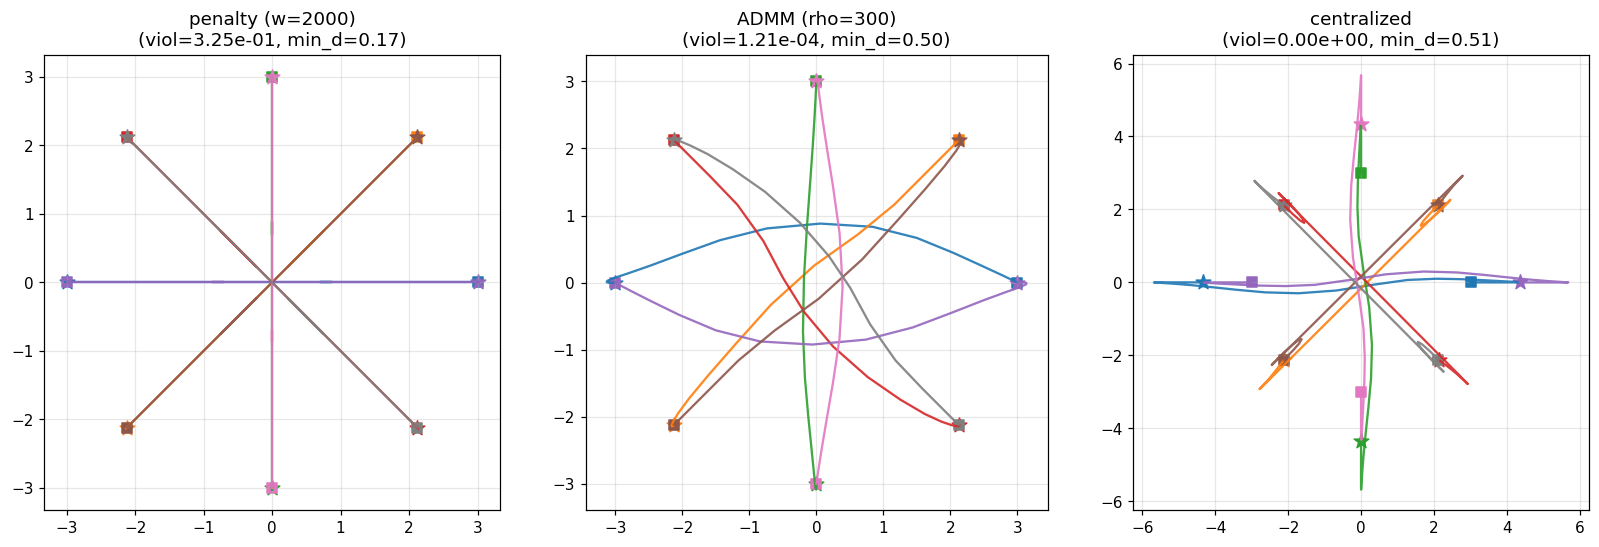

In [9]:
# Trajectory panels for S3 (penalty / ADMM / centralized)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
colors = plt.cm.tab10(np.arange(scn3.N))

for ax, r in zip(axes, [pr3, ar3, cr3]):
    for i in range(scn3.N):
        p = r.x[i, :, 0:2]
        ax.plot(p[:, 0], p[:, 1], "-", color=colors[i], alpha=0.9)
        ax.scatter(p[0, 0], p[0, 1], marker="s", color=colors[i], s=50)
        ax.scatter(p[-1, 0], p[-1, 1], marker="*", color=colors[i], s=100)
    ax.set_aspect("equal")
    ax.set_title(r.name + f"\n(viol={r.max_collision_violation:.2e}, min_d={r.min_pairwise_distance:.2f})")
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


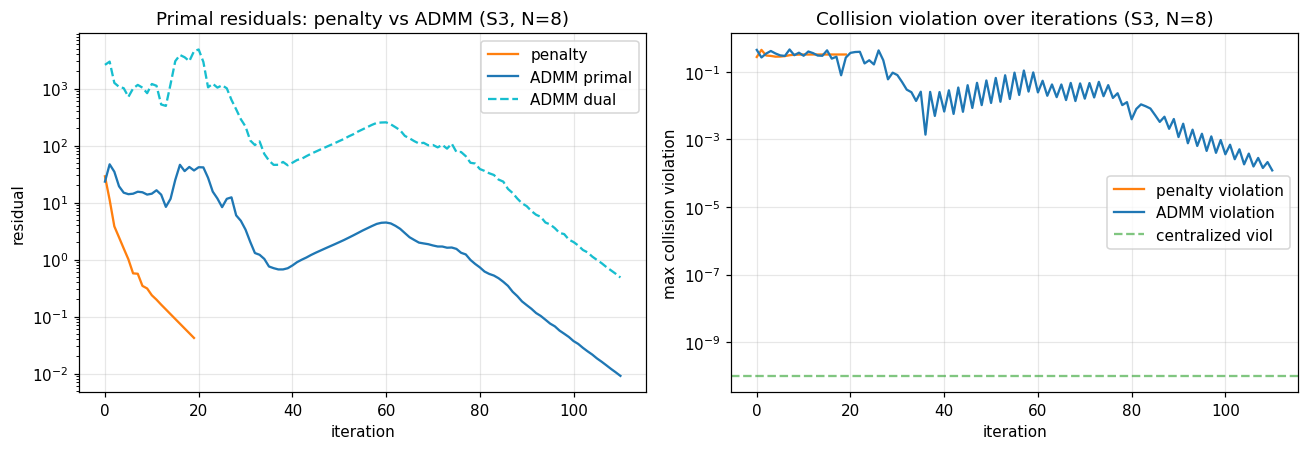

In [10]:
# Convergence comparison on S3: penalty vs ADMM
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

ax1.semilogy(pr3.history.primal_residual, color="tab:orange", label="penalty")
ax1.semilogy(ar3.history.primal_residual, color="tab:blue", label="ADMM primal")
ax1.semilogy(ar3.history.dual_residual, color="tab:cyan", ls="--", label="ADMM dual")
ax1.set_xlabel("iteration"); ax1.set_ylabel("residual")
ax1.set_title("Primal residuals: penalty vs ADMM (S3, N=8)")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.semilogy([max(v, 1e-10) for v in pr3.history.constraint_violation],
             color="tab:orange", label="penalty violation")
ax2.semilogy([max(v, 1e-10) for v in ar3.history.constraint_violation],
             color="tab:blue", label="ADMM violation")
ax2.axhline(cr3.max_collision_violation + 1e-10, color="tab:green", ls="--",
            alpha=0.6, label="centralized viol")
ax2.set_xlabel("iteration"); ax2.set_ylabel("max collision violation")
ax2.set_title("Collision violation over iterations (S3, N=8)")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## Experiment 4: Penalty-weight `w` sensitivity on S2

The proposal's main observation about the penalty method: small `w` lets
the drones collide (large slack absorbs the violation), while large `w`
ill-conditions the QP and slows convergence. We sweep `w` across several
orders of magnitude and record converged violation, objective, and
iterations-to-converge.

In [11]:
ws = [1.0, 10.0, 100.0, 1000.0, 10000.0]
results = []
for w in ws:
    r = run_penalty(scn2, w=w, max_iter=200, eps_abs=1e-4, eps_rel=1e-3)
    results.append(r)
    print(f"w={w:>8.1f}  iters={r.iterations:>3d}  t={r.wall_time:5.2f}s  "
          f"J={r.final_objective:>8.2f}  viol={r.max_collision_violation:.3e}  "
          f"min_d={r.min_pairwise_distance:.3f}")

w=     1.0  iters=  3  t= 0.25s  J= 8919.16  viol=4.151e-01  min_d=0.085


w=    10.0  iters=  3  t= 0.25s  J= 8919.16  viol=4.151e-01  min_d=0.085


w=   100.0  iters=  4  t= 0.27s  J= 8919.16  viol=4.151e-01  min_d=0.085


w=  1000.0  iters= 99  t= 1.24s  J= 8944.80  viol=1.674e-02  min_d=0.483


w= 10000.0  iters=200  t= 2.51s  J= 8930.11  viol=2.419e-01  min_d=0.120


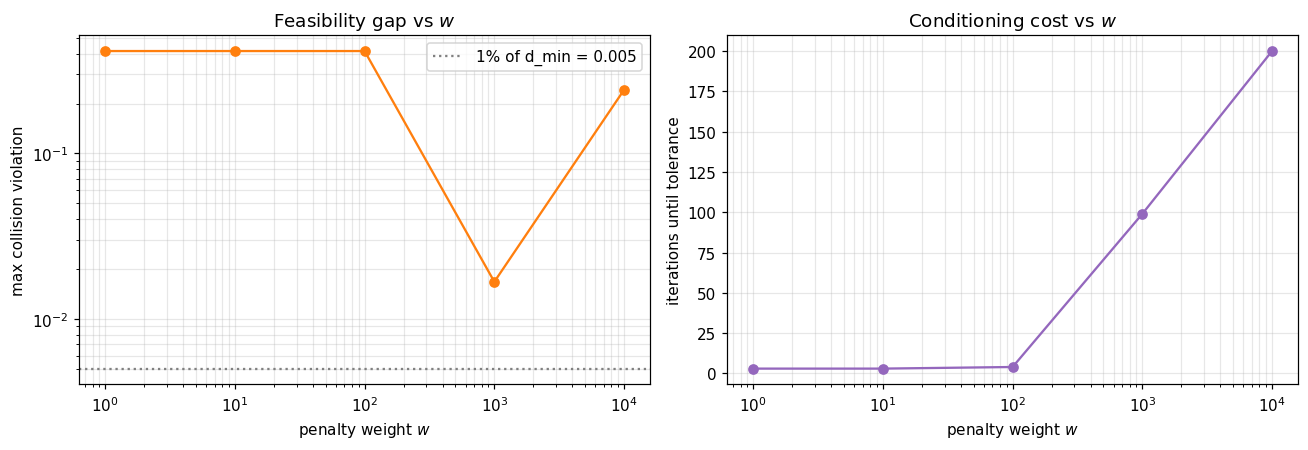

In [12]:
# Plot violation vs w and iterations vs w
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

ax1.loglog(ws, [max(r.max_collision_violation, 1e-10) for r in results], "o-", color="tab:orange")
ax1.axhline(scn2.d_min * 0.01, color="gray", ls=":", label=f"1% of d_min = {scn2.d_min*0.01:.3f}")
ax1.set_xlabel("penalty weight $w$"); ax1.set_ylabel("max collision violation")
ax1.set_title("Feasibility gap vs $w$")
ax1.legend(); ax1.grid(True, alpha=0.3, which="both")

ax2.semilogx(ws, [r.iterations for r in results], "o-", color="tab:purple")
ax2.set_xlabel("penalty weight $w$"); ax2.set_ylabel("iterations until tolerance")
ax2.set_title("Conditioning cost vs $w$")
ax2.grid(True, alpha=0.3, which="both")

plt.tight_layout(); plt.show()

## Takeaways

- Penalty converges on S1, S2, and S3 with a modest slack weight (`w=10³`
  on S1/S2; `w=2·10³` on S3 because N=8 coupling is tighter). On S3 it
  still leaves a noticeable feasibility gap — raising `w` further
  clusters the penalty trajectory too tightly for the centralized SCP
  seed.
- ADMM scales to N=8, but only with non-default tuning: penalty-seeded
  `initial_guess`, `rho=300`, `collision_slack_weight=1e7`. At those
  settings `viol ~ 1e-5`, matching centralized. With default
  `rho=5` it gets trapped at the symmetric straight-line warm-start.
- Centralized QP is the feasibility-enforcing reference at all three
  scales. On S3 the joint QP has ~1000+ variables per SCP round; the
  distributed methods' per-agent cost stays independent of N.
- The `w` sweep on S2 shows the proposal's main story: feasibility
  improves with `w` up to a point, then conditioning dominates and
  iteration count rises.
- The `rho` sweep in notebook 01 mirrors the `w` sweep for ADMM on S2:
  `rho` changes convergence speed but not the fixed point, so the
  feasibility gap stays flat while iterations vary by 1–2 orders of
  magnitude. That flatness is the key property penalty lacks.